# Wafer 夾爪機器人震動時間序列分析

讀取指定 CSV，檢查取樣品質，將訊號分解為趨勢、週期與殘差，並視覺化。先修改下一格的 `CSV_PATH`；如自動判斷欄位或週期不正確，可手動指定。

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
from statsmodels.tsa.seasonal import STL

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
# 可直接填絕對路徑；也可在執行前設定環境變數 CSV_PATH。
CSV_PATH = Path(os.getenv("CSV_PATH", r"../data/vibration.csv"))
TIME_COLUMN = None       # 例如 "timestamp"；None = 自動判斷
VALUE_COLUMNS = None     # 例如 ["accel_x", "accel_y", "accel_z"]；None = 全部數值欄
STL_PERIOD = None        # 一個週期的樣本數；None = 用頻譜自動估計
MAX_STL_POINTS = 50_000  # 避免超長訊號讓 robust STL 耗時過久

CSV_PATH = CSV_PATH.expanduser().resolve()
if not CSV_PATH.exists():
    raise FileNotFoundError(f"找不到 CSV：{CSV_PATH}。請修改 CSV_PATH 後重新執行。")
print(f"CSV: {CSV_PATH}")


CSV: C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\上手J5\RecData--20260827115016.csv


In [3]:
# 自動跳過 RecData 等儀器匯出的中繼資料列，並辨識常見分隔符。
with CSV_PATH.open("r", encoding="utf-8-sig", errors="replace") as fh:
    preview = [fh.readline() for _ in range(50)]
header_row = next((i for i, line in enumerate(preview)
                   if len(line.strip()) > 0 and any(d in line for d in (",", ";", "\t"))
                   and any(k in line.lower() for k in ("time", "date", "時間"))), 0)
metadata_lines = [line.strip() for line in preview[:header_row] if line.strip() and not set(line.strip()) == {"="}]
raw = pd.read_csv(CSV_PATH, sep=None, engine="python", skiprows=header_row)
raw.columns = raw.columns.astype(str).str.strip()
if metadata_lines:
    print("檔案中繼資料：", *metadata_lines, sep="\n  ")
print(f"資料形狀：{raw.shape[0]:,} rows × {raw.shape[1]} columns")
display(raw.head())
display(raw.dtypes.rename("dtype").to_frame())


檔案中繼資料：
  Date/Time: 2026/08/27 11:50:16
  SamplingRate: 1024.0
  SensorMAC:
  Unit: g
資料形狀：359,936 rows × 4 columns


,Time,X-axis,Y-axis,Z-axis
0,0.000000,0.008854,-0.003086,-0.012704
1,0.000977,-0.010422,0.018877,-0.007517
2,0.001953,0.000242,0.015098,-0.008307
3,0.002930,-0.000155,-0.008591,0.014507
4,0.003906,0.004322,0.009753,0.010709


,dtype
Time,float64
X-axis,float64
Y-axis,float64
Z-axis,float64


In [4]:
def choose_time_column(frame, requested=None):
    if requested is not None:
        if requested not in frame.columns:
            raise KeyError(f"TIME_COLUMN={requested!r} 不在 CSV 欄位中")
        return requested
    hints = ("timestamp", "datetime", "date", "time", "時間", "日期")
    for hint in hints:
        for col in frame.columns:
            if hint in col.lower():
                return col
    return frame.columns[0]

def parse_time(values):
    numeric = pd.to_numeric(values, errors="coerce")
    if numeric.notna().mean() >= 0.95:
        return numeric.astype(float), "numeric"
    parsed = pd.to_datetime(values, errors="coerce")
    if parsed.notna().mean() < 0.95:
        raise ValueError("時間欄無法可靠解析；請設定正確的 TIME_COLUMN。")
    return parsed, "datetime"

time_col = choose_time_column(raw, TIME_COLUMN)
time_values, time_kind = parse_time(raw[time_col])
work = raw.drop(columns=time_col).copy()
for col in work.columns:
    work[col] = pd.to_numeric(work[col], errors="coerce")

value_cols = VALUE_COLUMNS or [c for c in work.columns if work[c].notna().any()]
missing = set(value_cols) - set(work.columns)
if missing:
    raise KeyError(f"VALUE_COLUMNS 不存在：{sorted(missing)}")
if not value_cols:
    raise ValueError("找不到可分析的數值欄。")

data = work[value_cols].copy()
data.index = pd.Index(time_values, name=time_col)
data = data.loc[~data.index.isna()].sort_index()
data = data.groupby(level=0).mean()
data = data.interpolate(method="linear", limit_direction="both").dropna(axis=1)
print(f"時間欄：{time_col!r} ({time_kind})；訊號欄：{list(data.columns)}")


時間欄：'Time' (numeric)；訊號欄：['X-axis', 'Y-axis', 'Z-axis']


In [5]:
# 檢查取樣間隔；STL 需要等間距資料，因此必要時線性重取樣。
if len(data) < 10:
    raise ValueError("有效資料少於 10 筆，無法進行可靠分解。")

if time_kind == "datetime":
    seconds = data.index.to_series().diff().dt.total_seconds().dropna()
else:
    seconds = pd.Series(np.diff(data.index.to_numpy(dtype=float)))
seconds = seconds[seconds > 0]
dt = float(seconds.median())
jitter = float((seconds - dt).abs().median() / dt) if dt > 0 else np.nan
if not np.isfinite(dt) or dt <= 0:
    raise ValueError("無法推算正取樣間隔。")

if jitter > 0.01:
    if time_kind == "datetime":
        freq = pd.to_timedelta(dt, unit="s")
        regular_index = pd.date_range(data.index.min(), data.index.max(), freq=freq)
    else:
        regular_index = np.arange(float(data.index.min()), float(data.index.max()) + dt / 2, dt)
    data = data.reindex(data.index.union(regular_index)).interpolate(method="index").reindex(regular_index)
    data.index.name = time_col

fs = 1.0 / dt
print(f"中位取樣間隔：{dt:.6g} s；取樣率：約 {fs:.3f} Hz；間隔抖動：{jitter:.2%}")


中位取樣間隔：0.000976562 s；取樣率：約 1024.001 Hz；間隔抖動：0.00%


,count,mean,std,min,25%,50%,75%,max
X-axis,359936.0,-6.094756e-06,0.100065,-0.804620,-0.032011,0.000338,0.032579,0.811142
Y-axis,359936.0,-6.666352e-06,0.106029,-0.964001,-0.036134,-0.000517,0.035660,0.949299
Z-axis,359936.0,5.016975e-07,0.054572,-1.092902,-0.019842,-0.000447,0.019150,1.127728


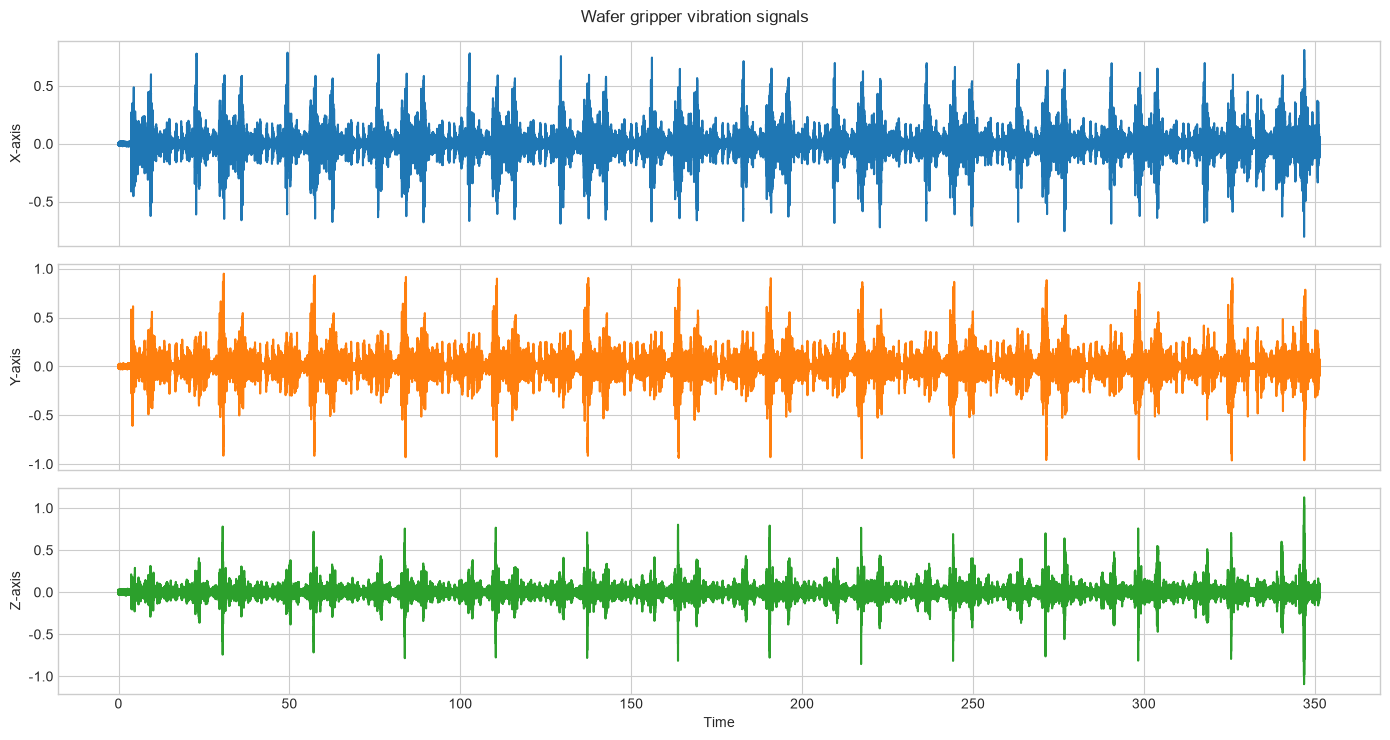

In [6]:
display(data.describe().T)
axes = data.plot(subplots=True, sharex=True, figsize=(14, max(4, 2.5 * len(data.columns))),
                 title="Wafer gripper vibration signals", legend=False)
for ax, col in zip(np.atleast_1d(axes), data.columns):
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()


In [7]:
def estimate_period(values, sample_rate):
    x = np.asarray(values, dtype=float)
    x = signal.detrend(x)
    freqs, power = signal.periodogram(x, fs=sample_rate)
    valid = (freqs > 0) & np.isfinite(power)
    if not valid.any() or np.nanmax(power[valid]) <= 0:
        return max(2, min(len(x) // 10, 100))
    dominant_frequency = freqs[valid][np.argmax(power[valid])]
    return int(np.clip(round(sample_rate / dominant_frequency), 2, max(2, len(x) // 3)))

analysis = data
if len(analysis) > MAX_STL_POINTS:
    step = int(np.ceil(len(analysis) / MAX_STL_POINTS))
    analysis = analysis.iloc[::step]
    analysis_fs = fs / step
    print(f"STL 將每 {step} 點取 1 點（{len(analysis):,} 點）以控制運算時間。")
else:
    analysis_fs = fs

periods = {}
decompositions = {}
for col in analysis.columns:
    period = int(STL_PERIOD) if STL_PERIOD else estimate_period(analysis[col], analysis_fs)
    if period >= len(analysis) // 2:
        raise ValueError(f"{col}: STL_PERIOD={period} 過大；請設定小於資料長度一半的值。")
    periods[col] = period
    decompositions[col] = STL(analysis[col], period=period, robust=True).fit()
display(pd.DataFrame({"STL period (samples)": periods,
                      "estimated cycle (seconds)": {k: v / analysis_fs for k, v in periods.items()}}))


STL 將每 8 點取 1 點（44,992 點）以控制運算時間。


,STL period (samples),estimated cycle (seconds)
X-axis,59,0.460937
Y-axis,58,0.453125
Z-axis,5,0.039062


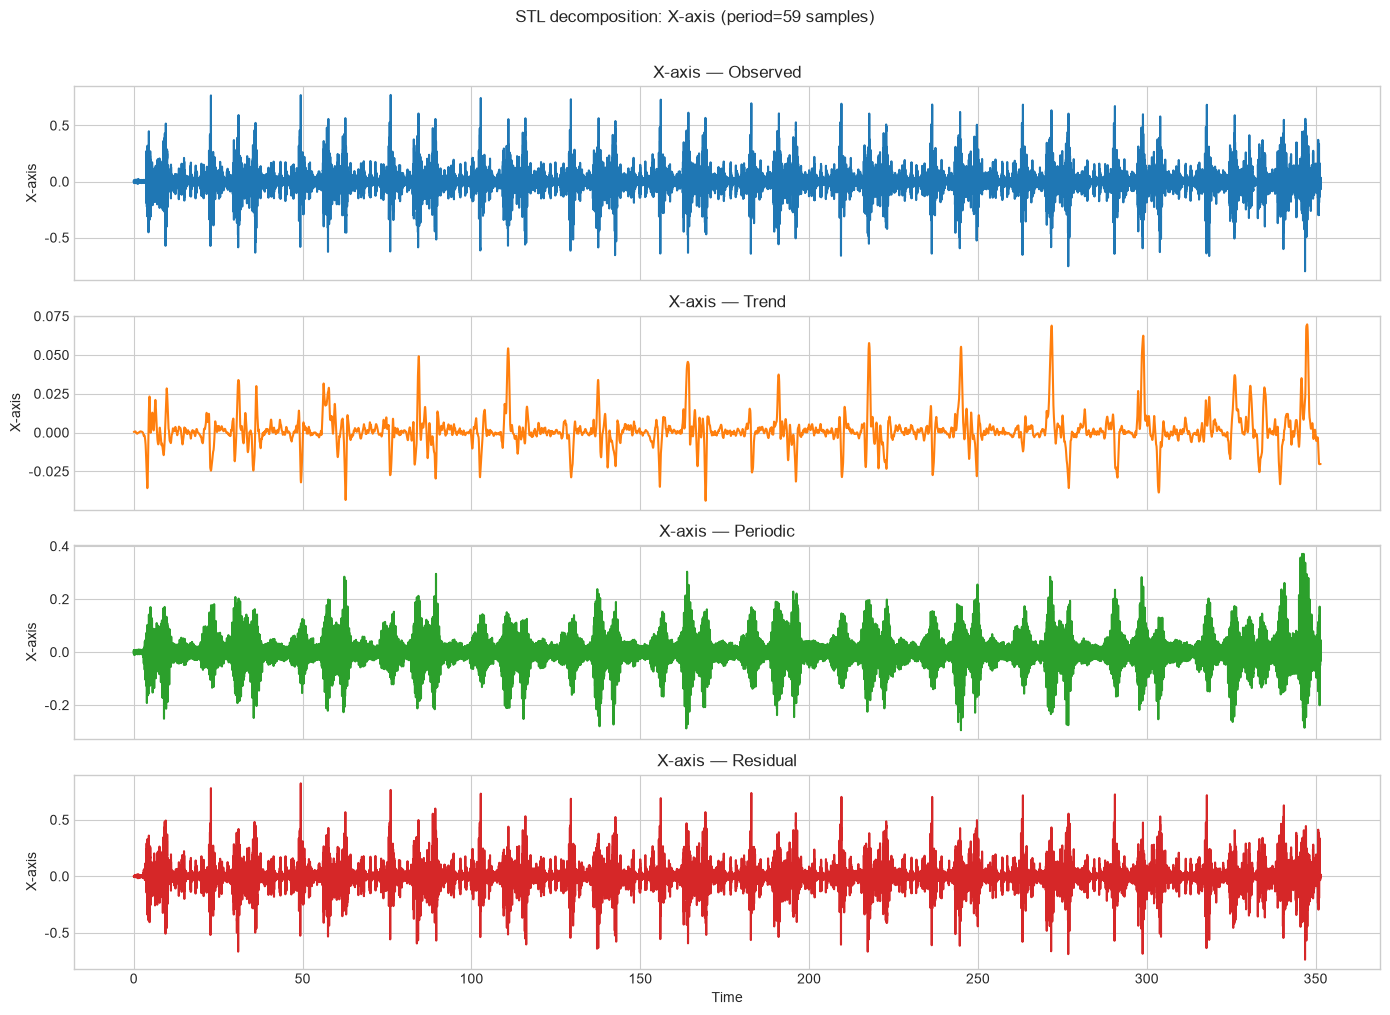

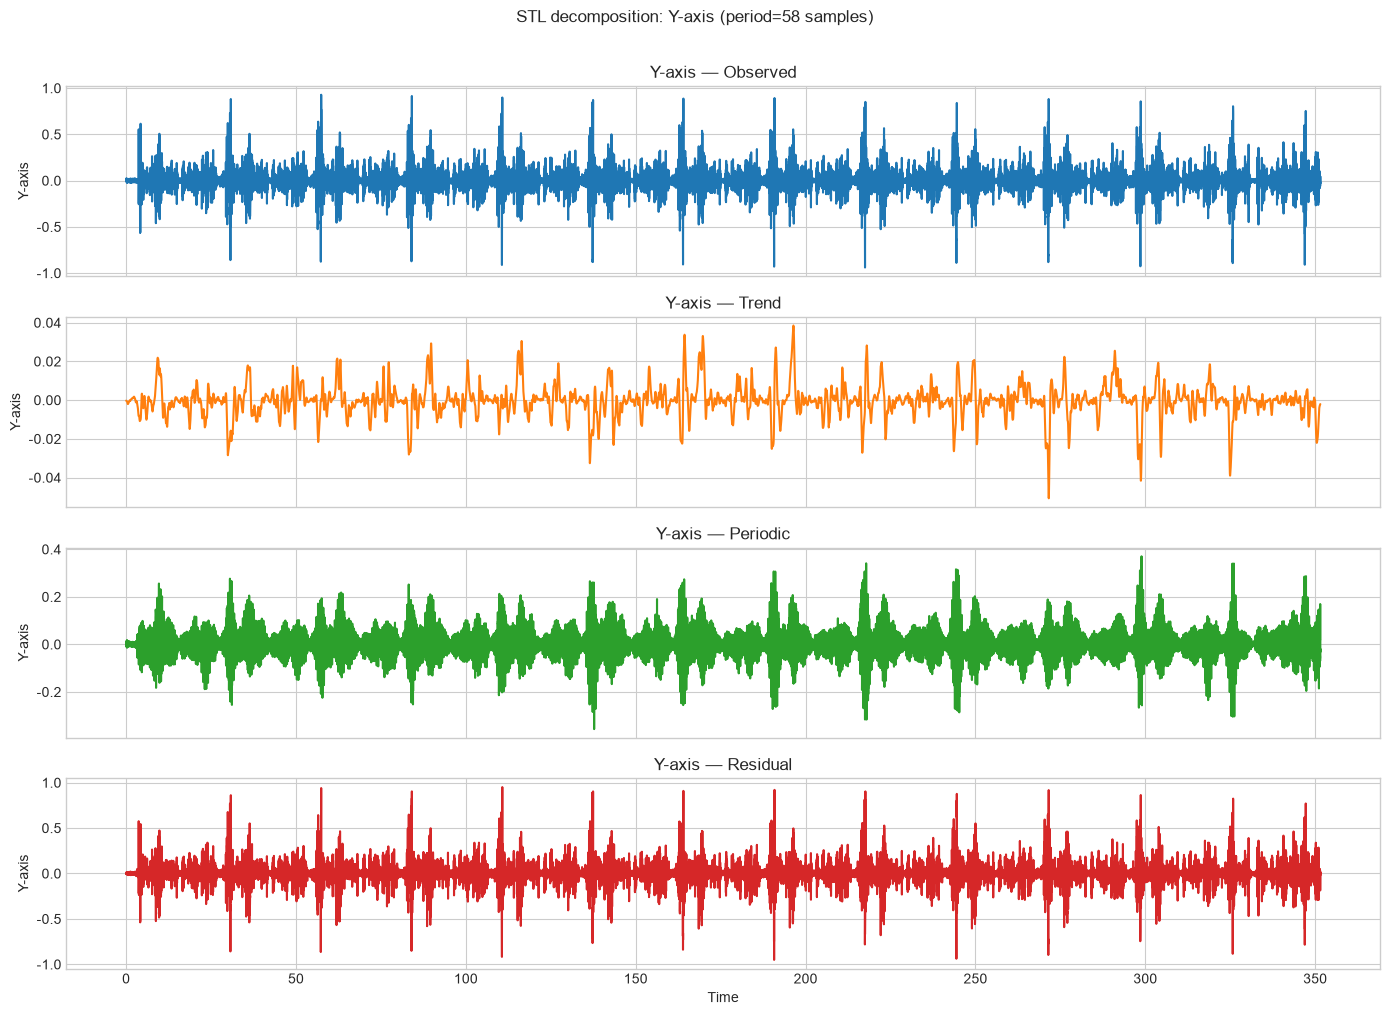

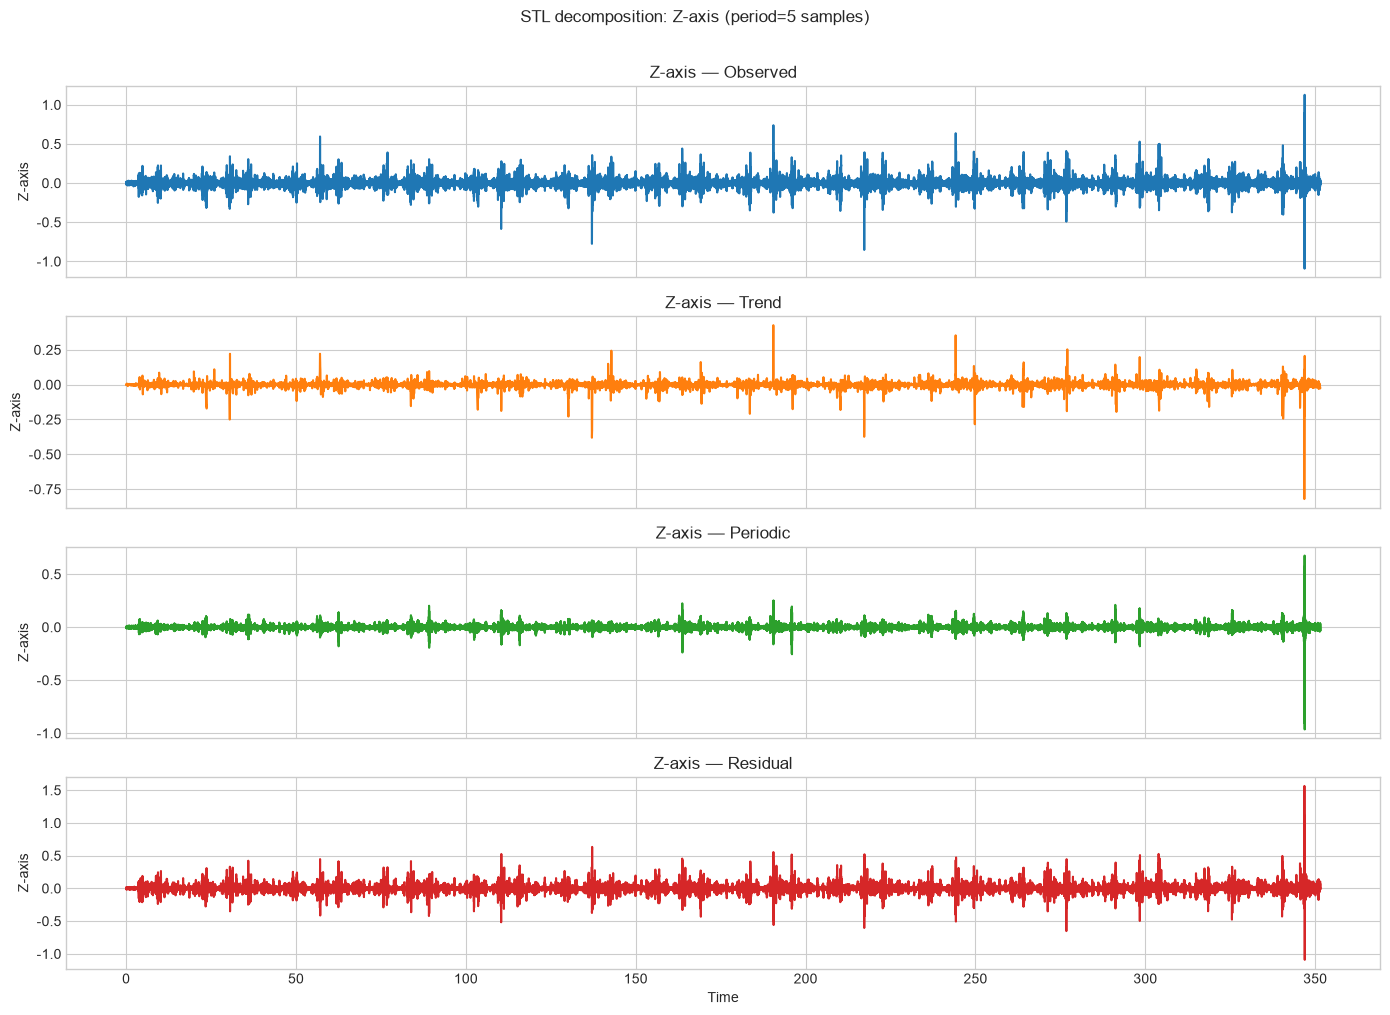

In [8]:
for col, result in decompositions.items():
    components = pd.DataFrame({
        "Observed": result.observed,
        "Trend": result.trend,
        "Periodic": result.seasonal,
        "Residual": result.resid,
    }, index=analysis.index)
    axes = components.plot(subplots=True, sharex=True, figsize=(14, 10), legend=False,
                           title=[f"{col} — {name}" for name in components.columns])
    for ax in np.atleast_1d(axes):
        ax.set_ylabel(col)
    plt.suptitle(f"STL decomposition: {col} (period={periods[col]} samples)", y=1.01)
    plt.tight_layout()
    plt.show()


In [9]:
# 初步震動指標：RMS、峰值、峰對峰值、crest factor，以及殘差 RMS。
rows = []
for col, result in decompositions.items():
    x = analysis[col].to_numpy()
    rms = float(np.sqrt(np.mean(np.square(x))))
    peak = float(np.max(np.abs(x)))
    rows.append({"signal": col, "RMS": rms, "peak": peak,
                 "peak_to_peak": float(np.ptp(x)),
                 "crest_factor": peak / rms if rms else np.nan,
                 "residual_RMS": float(np.sqrt(np.mean(np.square(result.resid))))})
metrics = pd.DataFrame(rows).set_index("signal")
display(metrics)


,RMS,peak,peak_to_peak,crest_factor,residual_RMS
signal,,,,,
X-axis,0.100100,0.800814,1.573328,8.000145,0.088797
Y-axis,0.105985,0.939947,1.868504,8.868720,0.096087
Z-axis,0.054469,1.127728,2.220630,20.704045,0.049481


## 解讀與下一步

- **Trend**：慢速漂移、姿態改變或熱效應。
- **Periodic**：重複運動、馬達轉速或機構共振造成的週期成分。
- **Residual**：非週期震動、衝擊與雜訊；殘差突然增大可作為異常候選。
- 自動週期只是起點。若已知馬達轉速、robot cycle time 或取樣率，應手動設定 `STL_PERIOD`。
- 後續可加入 Welch PSD、spectrogram、order tracking、滑動 RMS／kurtosis，以及依 robot motion phase 分段比較。